
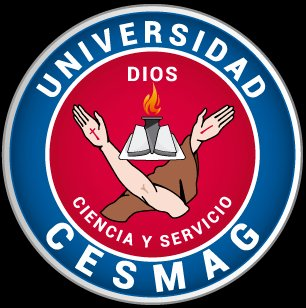

In [1]:
#@title  Notebook 03 — Evaluación Comparativa ECG
#@markdown (portada — no modificar)
from IPython.display import display, HTML
display(HTML("""
  <!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:ital,wght@0,300;0,400;0,600;1,300&family=JetBrains+Mono:wght@400;600&family=Barlow+Condensed:wght@300;400;700;900&display=swap');

  :root {
    --azul-cesmag: #003b7a;
    --rojo-cesmag: #c0002a;
    --dorado: #c9a84c;
    --crema: #f7f4ee;
    --gris-oscuro: #1a1a2e;
    --gris-medio: #4a4a6a;
    --blanco: #ffffff;
    --verde-ok: #2d9c5a;
    --pulso: #e8325a;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }

  body {
    font-family: 'Barlow Condensed', sans-serif;
    background: transparent;
  }

  .wrapper {
    width: 100%;
    background: var(--gris-oscuro);
    border-radius: 16px;
    overflow: hidden;
    position: relative;
    box-shadow: 0 24px 80px rgba(0,0,0,0.5);
  }

  /* ── ECG animado de fondo ── */
  .ecg-bg {
    position: absolute;
    top: 0; left: 0; right: 0; bottom: 0;
    opacity: 0.04;
    pointer-events: none;
    overflow: hidden;
  }
  .ecg-bg svg { width: 200%; height: 100%; animation: scrollECG 18s linear infinite; }
  @keyframes scrollECG {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }

  /* ── HEADER ── */
  .header {
    background: linear-gradient(135deg, var(--azul-cesmag) 0%, #001f4d 60%, #0a0a2a 100%);
    padding: 36px 48px 28px;
    display: grid;
    grid-template-columns: 110px 1fr;
    gap: 32px;
    align-items: center;
    position: relative;
    border-bottom: 3px solid var(--dorado);
  }

  .header::after {
    content: '';
    position: absolute;
    bottom: -3px; left: 0; right: 0;
    height: 1px;
    background: linear-gradient(90deg, transparent, var(--dorado), transparent);
  }

  .logo-ring {
    width: 110px; height: 110px;
    border-radius: 50%;
    padding: 4px;
    background: conic-gradient(var(--dorado), var(--rojo-cesmag), var(--dorado));
    animation: rotatering 8s linear infinite;
    flex-shrink: 0;
  }
  @keyframes rotatering {
    to { filter: hue-rotate(30deg); }
  }
  .logo-inner {
    width: 100%; height: 100%;
    border-radius: 50%;
    overflow: hidden;
    border: 3px solid var(--gris-oscuro);
  }
  .logo-inner img { width: 100%; height: 100%; object-fit: cover; }

  .header-text {}
  .univ-label {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 300;
    font-size: 11px;
    letter-spacing: 4px;
    color: var(--dorado);
    text-transform: uppercase;
    margin-bottom: 4px;
  }
  .univ-name {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 900;
    font-size: 28px;
    color: var(--blanco);
    letter-spacing: 1px;
    line-height: 1;
  }
  .dept {
    font-size: 13px;
    font-weight: 400;
    color: rgba(255,255,255,0.6);
    letter-spacing: 2px;
    margin-top: 6px;
  }

  .notebook-badge {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    background: var(--rojo-cesmag);
    color: white;
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    padding: 5px 14px;
    border-radius: 4px;
    margin-top: 12px;
    letter-spacing: 1px;
  }
  .notebook-badge::before {
    content: '▶';
    font-size: 8px;
  }

  /* ── TÍTULO PRINCIPAL ── */
  .title-section {
    padding: 32px 48px 24px;
    background: #111128;
    position: relative;
  }
  .title-label {
    font-size: 10px;
    letter-spacing: 5px;
    color: var(--pulso);
    text-transform: uppercase;
    margin-bottom: 10px;
    font-weight: 400;
  }
  .main-title {
    font-family: 'Crimson Pro', serif;
    font-size: 34px;
    font-weight: 600;
    color: var(--blanco);
    line-height: 1.25;
    max-width: 820px;
  }
  .main-title em {
    font-style: italic;
    color: var(--dorado);
  }
  .subtitle {
    font-family: 'Barlow Condensed', sans-serif;
    font-size: 14px;
    color: rgba(255,255,255,0.45);
    margin-top: 10px;
    letter-spacing: 1px;
    font-weight: 300;
  }

  /* ── GRID DE STATS ── */
  .stats-band {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    background: #0c0c22;
    border-top: 1px solid rgba(201,168,76,0.2);
    border-bottom: 1px solid rgba(201,168,76,0.2);
  }
  .stat-box {
    padding: 18px 20px;
    text-align: center;
    border-right: 1px solid rgba(255,255,255,0.06);
    position: relative;
    transition: background 0.3s;
  }
  .stat-box:last-child { border-right: none; }
  .stat-box:hover { background: rgba(201,168,76,0.05); }
  .stat-num {
    font-family: 'JetBrains Mono', monospace;
    font-size: 28px;
    font-weight: 600;
    color: var(--dorado);
    line-height: 1;
  }
  .stat-num span { font-size: 14px; color: rgba(201,168,76,0.6); }
  .stat-desc {
    font-size: 10px;
    letter-spacing: 2px;
    color: rgba(255,255,255,0.4);
    text-transform: uppercase;
    margin-top: 5px;
  }

  /* ── CUERPO PRINCIPAL ── */
  .body-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 0;
    background: #12122a;
  }

  .section {
    padding: 28px 32px;
    border-right: 1px solid rgba(255,255,255,0.05);
    border-bottom: 1px solid rgba(255,255,255,0.05);
  }
  .section:nth-child(even) { border-right: none; }

  .sec-title {
    font-size: 9px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: var(--pulso);
    margin-bottom: 14px;
    display: flex;
    align-items: center;
    gap: 8px;
  }
  .sec-title::after {
    content: '';
    flex: 1;
    height: 1px;
    background: rgba(232,50,90,0.3);
  }

  /* Modelos */
  .model-list { display: flex; flex-direction: column; gap: 7px; }
  .model-item {
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 8px 12px;
    background: rgba(255,255,255,0.03);
    border-radius: 6px;
    border-left: 3px solid transparent;
    transition: border-color 0.2s, background 0.2s;
  }
  .model-item:hover { background: rgba(255,255,255,0.07); }
  .model-item.winner { border-left-color: var(--dorado); }
  .model-item.good { border-left-color: var(--verde-ok); }
  .model-item.bad { border-left-color: var(--rojo-cesmag); }
  .model-tag {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    color: var(--blanco);
    min-width: 70px;
  }
  .model-score {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: rgba(255,255,255,0.5);
    margin-left: auto;
  }
  .crown { font-size: 10px; }

  /* Pipeline chips */
  .chip-grid { display: flex; flex-wrap: wrap; gap: 6px; }
  .chip {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    padding: 4px 10px;
    border-radius: 4px;
    background: rgba(0,59,122,0.4);
    border: 1px solid rgba(0,59,122,0.8);
    color: rgba(255,255,255,0.8);
    letter-spacing: 0.5px;
  }
  .chip.highlight {
    background: rgba(201,168,76,0.15);
    border-color: rgba(201,168,76,0.5);
    color: var(--dorado);
  }

  /* Métricas */
  .metric-row {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 7px 0;
    border-bottom: 1px solid rgba(255,255,255,0.04);
    font-size: 12px;
  }
  .metric-row:last-child { border-bottom: none; }
  .metric-name { color: rgba(255,255,255,0.5); font-weight: 300; letter-spacing: 1px; }
  .metric-val {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: var(--blanco);
    background: rgba(255,255,255,0.06);
    padding: 2px 8px;
    border-radius: 3px;
  }

  /* Archivos */
  .file-list { display: flex; flex-direction: column; gap: 5px; }
  .file-item {
    display: flex;
    align-items: center;
    gap: 8px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.55);
    padding: 5px 8px;
    border-radius: 4px;
    background: rgba(255,255,255,0.02);
  }
  .file-item .ftype {
    font-size: 8px;
    padding: 1px 5px;
    border-radius: 2px;
    font-weight: 600;
    letter-spacing: 1px;
  }
  .ftype.csv { background: rgba(45,156,90,0.3); color: #5de89e; }
  .ftype.png { background: rgba(201,168,76,0.3); color: var(--dorado); }
  .ftype.json { background: rgba(0,59,122,0.5); color: #5fa8ff; }
  .ftype.joblib { background: rgba(232,50,90,0.3); color: #ff7a9a; }

  /* ── AUTORES ── */
  .authors-bar {
    background: linear-gradient(90deg, #001530, #0a0a2a, #001530);
    padding: 20px 48px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    flex-wrap: wrap;
    gap: 16px;
    border-top: 1px solid rgba(201,168,76,0.2);
  }
  .authors-group { display: flex; flex-direction: column; gap: 6px; }
  .author-label {
    font-size: 8px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: rgba(255,255,255,0.3);
  }
  .author-names {
    display: flex;
    gap: 20px;
    flex-wrap: wrap;
  }
  .author {
    font-family: 'Crimson Pro', serif;
    font-size: 16px;
    color: var(--blanco);
    font-weight: 400;
    letter-spacing: 0.5px;
  }
  .asesor-block { text-align: right; }
  .asesor-name {
    font-family: 'Crimson Pro', serif;
    font-size: 15px;
    color: var(--dorado);
    font-style: italic;
  }

  /* ── FOOTER ── */
  .footer {
    background: #0a0a18;
    padding: 12px 48px;
    display: flex;
    justify-content: space-between;
    align-items: center;
  }
  .footer-date {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.2);
    letter-spacing: 2px;
  }
  .footer-file {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(232,50,90,0.5);
    letter-spacing: 1px;
  }

  /* ── ECG pulse line ── */
  .pulse-line {
    width: 100%;
    height: 40px;
    background: #0a0a18;
    position: relative;
    overflow: hidden;
  }
  .pulse-line svg {
    position: absolute;
    top: 0; left: 0;
    width: 200%;
    animation: pulsemove 3s linear infinite;
  }
  @keyframes pulsemove {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }


</style>
</head>
<body>
<div class="wrapper">

  <!-- ECG fondo decorativo -->
  <div class="ecg-bg">
    <svg viewBox="0 0 1400 200" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,100 80,100 100,100 110,20 120,180 130,60 140,140 150,100 230,100 310,100 320,100 330,20 340,180 350,60 360,140 370,100 450,100 530,100 540,100 550,20 560,180 570,60 580,140 590,100 670,100 750,100 760,100 770,20 780,180 790,60 800,140 810,100 890,100 970,100 980,100 990,20 1000,180 1010,60 1020,140 1030,100 1110,100 1190,100 1200,100 1210,20 1220,180 1230,60 1240,140 1250,100 1330,100 1400,100" stroke="white" stroke-width="2" fill="none"/>
    </svg>
  </div>

  <!-- HEADER -->
  <div class="header">
    <div class="logo-ring">
      <div class="logo-inner">
        <img src="..." alt="Logo CESMAG">
      </div>
    </div>
    <div class="header-text">
      <div class="univ-label">Universidad</div>
      <div class="univ-name">CESMAG</div>
      <div class="dept">Ingeniería de Sistemas · Grupo de Investigación</div>
      <div class="notebook-badge">03_evaluation.ipynb</div>
    </div>
  </div>

  <!-- TÍTULO -->
  <div class="title-section">
    <div class="title-label">Notebook 03 — Evaluación Comparativa</div>
    <div class="main-title">
      Evaluación Comparativa: Modelos <em>Intra-paciente</em><br>vs <em>Cross-patient</em> para Predicción ECG
    </div>
    <div class="subtitle">MIT-BIH Arrhythmia Database · 48 pacientes · 360 Hz · 3 Experimentos · 5 Modelos</div>
  </div>

  <!-- STATS -->
  <div class="stats-band">
    <div class="stat-box">
      <div class="stat-num">5</div>
      <div class="stat-desc">Modelos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">3</div>
      <div class="stat-desc">Experimentos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">48</div>
      <div class="stat-desc">Pacientes</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">0.616</div>
      <div class="stat-desc">R² NB5B (Recom.)</div>
    </div>
  </div>

  <!-- BODY GRID -->
  <div class="body-grid">

    <!-- Experimento A -->
    <div class="section">
      <div class="sec-title">Exp A · Evaluación Estándar (10 pac.)</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">NB1</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Trad. Intra</span>
          <span class="model-score">R²= 0.587</span>
        </div>
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">NB2</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">DL Intra</span>
          <span class="model-score">R²= 0.584</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">NB5B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">LOPO Cross</span>
          <span class="model-score">R²= 0.397</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">NB4B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Multi-sujeto</span>
          <span class="model-score">R²= 0.346</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">Persist.</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Baseline</span>
          <span class="model-score">R²= 0.085</span>
        </div>
      </div>
      <div style="margin-top:12px;font-size:10px;color:rgba(255,255,255,0.3);font-family:'JetBrains Mono',monospace;">
        Intra-paciente domina en datos propios (esperable)
      </div>
    </div>

    <!-- Experimento B -->
    <div class="section">
      <div class="sec-title">Exp B · Transferencia Cruzada (Clave)</div>
      <div class="model-list">
        <div class="model-item good">
          <span class="crown">✓</span>
          <span class="model-tag">NB2 propio</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Mismo pac.</span>
          <span class="model-score">R²= +0.584</span>
        </div>
        <div class="model-item bad">
          <span class="crown">⚠</span>
          <span class="model-tag">NB2 ajeno</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Otro pac.</span>
          <span class="model-score">R²= −0.399</span>
        </div>
        <div class="model-item good">
          <span class="crown">✓</span>
          <span class="model-tag">NB5B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">LOPO global</span>
          <span class="model-score">R²= +0.397</span>
        </div>
        <div class="model-item good">
          <span class="crown">✓</span>
          <span class="model-tag">NB4B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Multi global</span>
          <span class="model-score">R²= +0.346</span>
        </div>
      </div>
      <div style="margin-top:12px;">
        <div class="metric-row">
          <span class="metric-name">Caída media al transferir NB2</span>
          <span class="metric-val">−0.983</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Transferencias R² < 0</span>
          <span class="metric-val">33/50 (66%)</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Peor transferencia</span>
          <span class="metric-val">R²= −4.28</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">NB4B/NB5B > NB2 ajeno</span>
          <span class="metric-val">10/10 (100%)</span>
        </div>
      </div>
    </div>

    <!-- Experimento C -->
    <div class="section">
      <div class="sec-title">Exp C · Escenario Clínico (48 pac.)</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">NB5B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">LOPO · recom.</span>
          <span class="model-score">R²= 0.616</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">NB4B</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Multi-sujeto</span>
          <span class="model-score">R²= 0.418</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">Persist.</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Baseline</span>
          <span class="model-score">R²= 0.178</span>
        </div>
        <div class="model-item bad">
          <span class="crown">✗</span>
          <span class="model-tag">NB1/NB2</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">No aplica</span>
          <span class="model-score">0/48 cobertura</span>
        </div>
      </div>
      <div style="margin-top:12px;">
        <div class="metric-row">
          <span class="metric-name">NB5B > NB4B</span>
          <span class="metric-val">39/48 (81%)</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">NB5B R² > 0</span>
          <span class="metric-val">47/48 (98%)</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">NB5B R² > 0.5</span>
          <span class="metric-val">34/48 (71%)</span>
        </div>
      </div>
    </div>

    <!-- Síntesis + Archivos -->
    <div class="section">
      <div class="sec-title">Síntesis & Conclusiones</div>
      <div class="chip-grid" style="margin-bottom:14px;">
        <span class="chip highlight">NB5B Recomendado ★</span>
        <span class="chip highlight">LOPO 100% cobertura</span>
        <span class="chip">Intra-pac. 0% cobertura</span>
        <span class="chip">NB4B alternativa viable</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">NB1/NB2 R² propio</span>
        <span class="metric-val">0.58</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">NB1/NB2 R² ajeno</span>
        <span class="metric-val">−0.40</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">NB5B R² 48 pacientes</span>
        <span class="metric-val">0.616</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">NB4B R² 48 pacientes</span>
        <span class="metric-val">0.418</span>
      </div>
      <div style="margin-top:14px;">
        <div class="sec-title">Archivos Generados</div>
        <div class="file-list">
          <div class="file-item"><span class="ftype csv">CSV</span>expA_evaluacion_estandar.csv</div>
          <div class="file-item"><span class="ftype csv">CSV</span>expB_transferencia_cruzada.csv</div>
          <div class="file-item"><span class="ftype csv">CSV</span>expB_resumen.csv</div>
          <div class="file-item"><span class="ftype csv">CSV</span>expC_escenario_clinico.csv</div>
        </div>
      </div>
    </div>

  </div>

  <!-- ECG PULSE LINE -->
  <div class="pulse-line">
    <svg viewBox="0 0 1400 40" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,20 100,20 120,20 130,4 140,36 148,12 156,28 164,20 264,20 364,20 374,20 384,4 394,36 402,12 410,28 418,20 518,20 618,20 628,20 638,4 648,36 656,12 664,28 672,20 772,20 872,20 882,20 892,4 902,36 910,12 918,28 926,20 1026,20 1126,20 1136,20 1146,4 1156,36 1164,12 1172,28 1180,20 1280,20 1400,20"
        stroke="#e8325a" stroke-width="1.5" fill="none" opacity="0.6"/>
    </svg>
  </div>

  <!-- AUTHORS -->
  <div class="authors-bar">
    <div class="authors-group">
      <div class="author-label">Autores</div>
      <div class="author-names">
        <span class="author">Darwin David Burbano Guerrero</span>
        <span style="color:rgba(255,255,255,0.2);align-self:center;">·</span>
        <span class="author">Darío Esteban Gómez Ordóñez</span>
      </div>
    </div>
    <div class="asesor-block">
      <div class="author-label" style="text-align:right;">Asesor</div>
      <div class="asesor-name">Mg. Héctor Andrés Mora Paz</div>
    </div>
  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="footer-date">ANÁLISIS: 05 · ABR · 2026</div>
    <div class="footer-file">03_evaluation.ipynb</div>
  </div>

</div>
</body>
</html>

"""))


In [7]:
import os, sys, json, warnings, time, zipfile, tempfile, shutil, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import wfdb
import scipy.signal as spsig
from scipy.ndimage import median_filter
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from scipy.stats import friedmanchisquare, wilcoxon
import joblib

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Helper: cargar .keras eliminando quantization_config ---
def _strip_quant(obj):
    if isinstance(obj, dict):
        obj.pop('quantization_config', None)
        for v in obj.values():
            _strip_quant(v)
    elif isinstance(obj, list):
        for v in obj:
            _strip_quant(v)

def load_keras_safe(path):
    tmp_dir = tempfile.mkdtemp()
    try:
        patched = os.path.join(tmp_dir, 'model_patched.keras')
        with zipfile.ZipFile(path, 'r') as zin, zipfile.ZipFile(patched, 'w') as zout:
            for item in zin.infolist():
                data = zin.read(item.filename)
                if item.filename == 'config.json':
                    cfg = json.loads(data)
                    _strip_quant(cfg)
                    data = json.dumps(cfg).encode('utf-8')
                zout.writestr(item, data)
        return keras.models.load_model(patched, compile=False)
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.20.0


In [8]:
SEED       = 42
PROP_TRAIN = 0.80
FS         = 360
NYQUIST    = FS / 2
BEAT_LEN   = 256
F_BAJO, F_ALTO     = 0.5, 40.0
ORDEN_BUT           = 4
FREC_NOTCH, Q_NOTCH = 60.0, 30.0
BEAT_TYPES = set('NLRBVAFaJfEjeSe/')

RUTA_DATOS  = os.path.join('..', 'datos', 'mit-bih')
RESULTS_DIR = os.path.join('..', 'results')

PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

N_DONORS = 5   # modelos ajenos por paciente en Exp B
rng = np.random.RandomState(SEED)
SAMPLE_PIDS = sorted(rng.choice(PACIENTES, size=10, replace=False))

print(f"Pacientes: {len(PACIENTES)} | Muestra: {SAMPLE_PIDS}")


Pacientes: 48 | Muestra: [np.str_('104'), np.str_('113'), np.str_('121'), np.str_('201'), np.str_('202'), np.str_('203'), np.str_('205'), np.str_('219'), np.str_('222'), np.str_('230')]


In [9]:
# === Carga de senal ===
def cargar_ecg(pid):
    ruta = os.path.join(RUTA_DATOS, pid)
    rec  = wfdb.rdrecord(ruta)
    ann  = wfdb.rdann(ruta, 'atr')
    s    = rec.p_signal[:, 0].astype(np.float64)
    return s, ann

# === Filtros ===
def f_notch(s):
    b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
    return spsig.filtfilt(b, a, s)

def f_butter_bp(s):
    b, a = spsig.butter(ORDEN_BUT, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], btype='band')
    return spsig.filtfilt(b, a, s)

def f_mediana(s):
    k = FS // 10
    k = k if k % 2 == 1 else k + 1
    return median_filter(s, size=k)

FILTROS = {
    'F_SIN':       [],
    'F_N':         [f_notch],
    'F_PB':        [f_butter_bp],
    'F_MED':       [f_mediana],
    'F_N+PB':      [f_notch, f_butter_bp],
    'F_N+MED':     [f_notch, f_mediana],
    'F_N+PB+MED':  [f_notch, f_butter_bp, f_mediana],
}

def aplicar_filtro(senal, nombre_filtro):
    s = senal.copy()
    for fn in FILTROS[nombre_filtro]:
        s = fn(s)
    return s

# === Extraccion de latidos ===
def extraer_latidos(senal_filtrada, ann, beat_len=BEAT_LEN):
    mask   = [s in BEAT_TYPES for s in ann.symbol]
    rpeaks = ann.sample[mask]
    if len(rpeaks) < 10:
        return np.empty((0, beat_len), dtype=np.float32), rpeaks
    beats = []
    for i in range(1, len(rpeaks) - 1):
        start = (rpeaks[i-1] + rpeaks[i]) // 2
        end   = (rpeaks[i]   + rpeaks[i+1]) // 2
        seg   = senal_filtrada[start:end]
        if len(seg) < 50:
            continue
        beats.append(spsig.resample(seg, beat_len).astype(np.float32))
    if beats:
        return np.array(beats, dtype=np.float32), rpeaks
    return np.empty((0, beat_len), dtype=np.float32), rpeaks

# === Secuencias ===
def secuencias_flat(beats, n_lookback):
    if len(beats) <= n_lookback:
        return np.empty((0, n_lookback * BEAT_LEN)), np.empty((0, BEAT_LEN))
    X = np.array([beats[i:i+n_lookback].flatten()
                  for i in range(len(beats) - n_lookback)], dtype=np.float32)
    y = np.array([beats[i + n_lookback]
                  for i in range(len(beats) - n_lookback)], dtype=np.float32)
    return X, y

def secuencias_3d(beats, n_lookback):
    if len(beats) <= n_lookback:
        return np.empty((0, n_lookback, BEAT_LEN)), np.empty((0, BEAT_LEN))
    X = np.array([beats[i:i+n_lookback]
                  for i in range(len(beats) - n_lookback)], dtype=np.float32)
    y = np.array([beats[i + n_lookback]
                  for i in range(len(beats) - n_lookback)], dtype=np.float32)
    return X, y

# === Mascara de test comun (Opcion B) ===
def test_mask(n_secuencias, lb, idx_split):
    target_idx = np.arange(lb, lb + n_secuencias)
    return target_idx >= idx_split

def metricas(y_true, y_pred):
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    r2  = r2_score(yt, yp)
    mse = mean_squared_error(yt, yp)
    return {
        'R2':   round(r2, 4),
        'RMSE': round(np.sqrt(mse), 6),
        'MAE':  round(mean_absolute_error(yt, yp), 6),
    }

print("Funciones cargadas")


Funciones cargadas


In [10]:
# --- NB4B: GRU global ---
nb4b_path      = os.path.join(RESULTS_DIR, 'NB4B', 'modelos', 'modelo_GRU_F_N+MED.keras')
nb4b_norm_path = os.path.join(RESULTS_DIR, 'NB4B', 'modelos', 'norm_F_N+MED.json')

modelo_nb4b = load_keras_safe(nb4b_path)
with open(nb4b_norm_path) as fh:
    norm_nb4b = json.load(fh)
MU_NB4B  = norm_nb4b['mu']
STD_NB4B = norm_nb4b['std']
FILTRO_NB4B = 'F_N+MED'
LB_NB4B     = 5
print(f"NB4B: GRU global | mu={MU_NB4B:.4f} std={STD_NB4B:.4f}")

# --- NB5B: GRU cross-patient ---
nb5b_path      = os.path.join(RESULTS_DIR, 'NB5B', 'modelos', 'GRU_cross_patient_beatpool.keras')
nb5b_meta_path = os.path.join(RESULTS_DIR, 'NB5B', 'modelos', 'GRU_metadata.json')

modelo_nb5b = load_keras_safe(nb5b_path)
with open(nb5b_meta_path) as fh:
    meta_nb5b = json.load(fh)
FILTRO_NB5B = meta_nb5b['filtro']
LB_NB5B     = meta_nb5b['lookback']
print(f"NB5B: GRU LOPO | {FILTRO_NB5B} | lb={LB_NB5B}")


NB4B: GRU global | mu=-0.3609 std=0.4095
NB5B: GRU LOPO | F_N+PB+MED | lb=5


In [11]:
def eval_nb1(pid_model, pid_data, senal, ann, idx_split):
    # Evalua modelo NB1 de pid_model sobre datos de pid_data
    base       = os.path.join(RESULTS_DIR, 'NB1', 'modelos')
    model_path = os.path.join(base, f'ganador_B_pac{pid_model}_NB1.joblib')
    meta_path  = os.path.join(base, f'ganador_B_pac{pid_model}_NB1_metadata.json')
    if not os.path.exists(model_path):
        return None
    with open(meta_path) as fh:
        meta = json.load(fh)
    filtro = meta['config']['filtro']
    lb     = int(meta['config']['lookback'])

    senal_f  = aplicar_filtro(senal, filtro)
    beats, _ = extraer_latidos(senal_f, ann)
    if len(beats) <= lb or idx_split <= lb:
        return None

    train_beats = beats[:idx_split]
    mu  = float(train_beats.mean())
    std = max(float(train_beats.std()), 1e-8)
    beats_z = (beats - mu) / std

    X, y = secuencias_flat(beats_z, lb)
    mask = test_mask(len(X), lb, idx_split)
    X_te, y_te = X[mask], y[mask]
    if len(X_te) == 0:
        return None

    model  = joblib.load(model_path)

    # --- PCA refit: NB1 aplica PCA(50) a MLP/SVR cuando dims > 768 ---
    n_feats_model = model.n_features_in_
    if n_feats_model < X_te.shape[1]:
        X_tr = X[~mask]
        pca = PCA(n_components=n_feats_model, random_state=SEED)
        pca.fit(X_tr)
        X_te = pca.transform(X_te)

    y_pred = model.predict(X_te)

    res = metricas(y_te, y_pred)
    res['n_test'] = len(X_te)
    return res


def eval_nb2(pid_model, pid_data, senal, ann, idx_split):
    # Evalua modelo NB2 de pid_model sobre datos de pid_data
    base       = os.path.join(RESULTS_DIR, 'NB2', 'modelos')
    model_path = os.path.join(base, f'ganador_B_pac{pid_model}_NB2.keras')
    meta_path  = os.path.join(base, f'ganador_B_pac{pid_model}_NB2_metadata.json')
    if not os.path.exists(model_path):
        return None
    with open(meta_path) as fh:
        meta = json.load(fh)
    filtro = meta['config']['filtro']
    lb     = int(meta['config'].get('lookback', 5))

    senal_f  = aplicar_filtro(senal, filtro)
    beats, _ = extraer_latidos(senal_f, ann)
    if len(beats) <= lb or idx_split <= lb:
        return None

    train_beats = beats[:idx_split]
    mu  = float(train_beats.mean())
    std = max(float(train_beats.std()), 1e-8)
    beats_z = (beats - mu) / std

    X, y = secuencias_3d(beats_z, lb)
    mask = test_mask(len(X), lb, idx_split)
    X_te, y_te = X[mask], y[mask]
    if len(X_te) == 0:
        return None

    model  = load_keras_safe(model_path)
    y_pred = model.predict(X_te, verbose=0)

    res = metricas(y_te, y_pred)
    res['n_test'] = len(X_te)
    return res


def eval_nb4b(pid_data, senal, ann, idx_split):
    senal_f  = aplicar_filtro(senal, FILTRO_NB4B)
    beats, _ = extraer_latidos(senal_f, ann)
    if len(beats) <= LB_NB4B or idx_split <= LB_NB4B:
        return None

    beats_z = (beats - MU_NB4B) / STD_NB4B
    X, y = secuencias_3d(beats_z, LB_NB4B)
    mask = test_mask(len(X), LB_NB4B, idx_split)
    X_te, y_te = X[mask], y[mask]
    if len(X_te) == 0:
        return None

    y_pred = modelo_nb4b.predict(X_te, verbose=0)

    res = metricas(y_te, y_pred)
    res['n_test'] = len(X_te)
    return res


def eval_nb5b(pid_data, senal, ann, idx_split):
    senal_f  = aplicar_filtro(senal, FILTRO_NB5B)
    beats, _ = extraer_latidos(senal_f, ann)
    if len(beats) <= LB_NB5B or idx_split <= LB_NB5B:
        return None

    train_beats = beats[:idx_split]
    mu  = float(train_beats.mean())
    std = max(float(train_beats.std()), 1e-8)
    beats_z = (beats - mu) / std

    X, y = secuencias_3d(beats_z, LB_NB5B)
    mask = test_mask(len(X), LB_NB5B, idx_split)
    X_te, y_te = X[mask], y[mask]
    if len(X_te) == 0:
        return None

    y_pred = modelo_nb5b.predict(X_te, verbose=0)

    res = metricas(y_te, y_pred)
    res['n_test'] = len(X_te)
    return res


def eval_persistencia(pid_data, senal, ann, idx_split):
    filtro = 'F_N+MED'
    lb     = 5
    senal_f  = aplicar_filtro(senal, filtro)
    beats, _ = extraer_latidos(senal_f, ann)
    if len(beats) <= lb or idx_split <= lb:
        return None

    train_beats = beats[:idx_split]
    mu  = float(train_beats.mean())
    std = max(float(train_beats.std()), 1e-8)
    beats_z = (beats - mu) / std

    X, y = secuencias_3d(beats_z, lb)
    mask = test_mask(len(X), lb, idx_split)
    X_te, y_te = X[mask], y[mask]
    if len(X_te) == 0:
        return None

    y_pred = X_te[:, -1, :]

    res = metricas(y_te, y_pred)
    res['n_test'] = len(X_te)
    return res

print("Evaluadores definidos (NB1, NB2 aceptan pid_model != pid_data)")

Evaluadores definidos (NB1, NB2 aceptan pid_model != pid_data)


---
## Experimento A — Evaluación Estándar (cada modelo en SU paciente)

Cada modelo se evalúa en el paciente para el que fue entrenado.
Los modelos intra-paciente (NB1/NB2) deberían obtener el mejor R²
aquí, porque están especializados en esa morfología individual.

> **Pregunta**: ¿Quién tiene mejor R² en condiciones ideales?


In [12]:
expA = []
t0 = time.time()

for pid in SAMPLE_PIDS:
    senal, ann = cargar_ecg(pid)
    beats_count, _ = extraer_latidos(senal, ann)
    n_beats   = len(beats_count)
    idx_split = int(n_beats * PROP_TRAIN)

    print(f"\nPac {pid}: {n_beats} latidos | test={n_beats - idx_split}")

    # NB1 propio
    r = eval_nb1(pid, pid, senal, ann, idx_split)
    if r:
        expA.append({'Paciente': pid, 'Modelo': 'NB1', 'R2': r['R2'],
                     'RMSE': r['RMSE'], 'MAE': r['MAE'], 'n_test': r['n_test']})
        print(f"  NB1  R2={r['R2']:+.4f}")

    # NB2 propio
    r = eval_nb2(pid, pid, senal, ann, idx_split)
    if r:
        expA.append({'Paciente': pid, 'Modelo': 'NB2', 'R2': r['R2'],
                     'RMSE': r['RMSE'], 'MAE': r['MAE'], 'n_test': r['n_test']})
        print(f"  NB2  R2={r['R2']:+.4f}")

    # NB4B global
    r = eval_nb4b(pid, senal, ann, idx_split)
    if r:
        expA.append({'Paciente': pid, 'Modelo': 'NB4B', 'R2': r['R2'],
                     'RMSE': r['RMSE'], 'MAE': r['MAE'], 'n_test': r['n_test']})
        print(f"  NB4B R2={r['R2']:+.4f}")

    # NB5B global
    r = eval_nb5b(pid, senal, ann, idx_split)
    if r:
        expA.append({'Paciente': pid, 'Modelo': 'NB5B', 'R2': r['R2'],
                     'RMSE': r['RMSE'], 'MAE': r['MAE'], 'n_test': r['n_test']})
        print(f"  NB5B R2={r['R2']:+.4f}")

    # Persistencia
    r = eval_persistencia(pid, senal, ann, idx_split)
    if r:
        expA.append({'Paciente': pid, 'Modelo': 'Persistencia', 'R2': r['R2'],
                     'RMSE': r['RMSE'], 'MAE': r['MAE'], 'n_test': r['n_test']})
        print(f"  Pers R2={r['R2']:+.4f}")

dfA = pd.DataFrame(expA)
print(f"\nExp A completado en {time.time()-t0:.1f}s")



Pac 104: 2209 latidos | test=442
  NB1  R2=+0.8719
  NB2  R2=+0.8958
  NB4B R2=+0.3485
  NB5B R2=+0.7928
  Pers R2=+0.4280

Pac 113: 1793 latidos | test=359
  NB1  R2=+0.7866
  NB2  R2=+0.8156
  NB4B R2=+0.6244
  NB5B R2=+0.7848
  Pers R2=+0.6444

Pac 121: 1861 latidos | test=373
  NB1  R2=+0.7765
  NB2  R2=+0.6838
  NB4B R2=+0.6390
  NB5B R2=+0.5891
  Pers R2=+0.6210

Pac 201: 1961 latidos | test=393
  NB1  R2=+0.3168
  NB2  R2=+0.2796
  NB4B R2=+0.0023
  NB5B R2=-0.0404
  Pers R2=-0.5573

Pac 202: 2134 latidos | test=427
  NB1  R2=+0.3877
  NB2  R2=+0.4640
  NB4B R2=+0.3095
  NB5B R2=+0.3258
  Pers R2=-0.0595

Pac 203: 2974 latidos | test=595
  NB1  R2=+0.3610
  NB2  R2=+0.3822
  NB4B R2=+0.1666
  NB5B R2=+0.0294
  Pers R2=-0.3862

Pac 205: 2654 latidos | test=531
  NB1  R2=+0.6289
  NB2  R2=+0.4220
  NB4B R2=+0.2621
  NB5B R2=+0.2579
  Pers R2=-0.1817

Pac 219: 2152 latidos | test=431
  NB1  R2=+0.7047
  NB2  R2=+0.7283
  NB4B R2=+0.5218
  NB5B R2=+0.5148
  Pers R2=+0.2202

Pac 222

In [13]:
pivotA = dfA.pivot_table(index='Paciente', columns='Modelo', values='R2')
ORDEN_A = ['NB1', 'NB2', 'NB4B', 'NB5B', 'Persistencia']
pivotA = pivotA[[c for c in ORDEN_A if c in pivotA.columns]]

print("=== Exp A: R2 por Paciente (modelo propio) ===\n")
display(pivotA.round(4).style.background_gradient(cmap='RdYlGn', vmin=-0.5, vmax=1.0))

resA = dfA.groupby('Modelo')['R2'].agg(['mean','std','min','max']).round(4)
resA.columns = ['R2_medio', 'R2_std', 'R2_min', 'R2_max']
resA = resA.reindex([c for c in ORDEN_A if c in resA.index])
print("\n=== Resumen Exp A ===")
display(resA)


=== Exp A: R2 por Paciente (modelo propio) ===



Modelo,NB1,NB2,NB4B,NB5B,Persistencia
Paciente,,,,,
104,0.871900,0.895800,0.348500,0.792800,0.428000
113,0.786600,0.815600,0.624400,0.784800,0.644400
121,0.776500,0.683800,0.639000,0.589100,0.621000
201,0.316800,0.279600,0.002300,-0.040400,-0.557300
202,0.387700,0.464000,0.309500,0.325800,-0.059500
203,0.361000,0.382200,0.166600,0.029400,-0.386200
205,0.628900,0.422000,0.262100,0.257900,-0.181700
219,0.704700,0.728300,0.521800,0.514800,0.220200
222,0.267100,0.531500,0.185700,0.059700,-0.317100



=== Resumen Exp A ===


,R2_medio,R2_std,R2_min,R2_max
Modelo,,,,
NB1,0.5866,0.2286,0.2671,0.8719
NB2,0.5836,0.2002,0.2796,0.8958
NB4B,0.3458,0.2059,0.0023,0.6390
NB5B,0.3965,0.3139,-0.0404,0.7928
Persistencia,0.0854,0.4412,-0.5573,0.6444


---
## Experimento B — Transferencia Cruzada (modelo ajeno → paciente nuevo)

**Este es el experimento clave para la defensa.**

Para cada paciente target, se aplica el modelo NB2 entrenado en **otro paciente
distinto** (donante). Se repite con 5 donantes aleatorios.

- Si NB2 generaliza → R² ajeno ≈ R² propio
- Si NB2 memoriza → R² ajeno << R² propio (colapso)
- NB4B/NB5B: mismos valores que Exp A (son agnósticos al paciente)

> **Pregunta**: ¿Los modelos intra-paciente colapsan al ver un paciente nuevo?


In [14]:
expB = []
t0 = time.time()

for pid_target in SAMPLE_PIDS:
    senal, ann = cargar_ecg(pid_target)
    beats_count, _ = extraer_latidos(senal, ann)
    n_beats   = len(beats_count)
    idx_split = int(n_beats * PROP_TRAIN)

    print(f"\nTarget: {pid_target} ({n_beats} latidos)")

    # --- NB2 con modelo PROPIO ---
    r_own = eval_nb2(pid_target, pid_target, senal, ann, idx_split)
    if r_own:
        expB.append({'Paciente': pid_target, 'Escenario': 'NB2 (propio)',
                     'R2': r_own['R2'], 'n_test': r_own['n_test']})
        print(f"  NB2 propio  R2={r_own['R2']:+.4f}")

    # --- NB2 con modelos AJENOS (5 donantes) ---
    otros = [p for p in PACIENTES if p != pid_target]
    donantes = rng.choice(otros, size=N_DONORS, replace=False)

    r2_ajenos = []
    for pid_donor in donantes:
        r = eval_nb2(pid_donor, pid_target, senal, ann, idx_split)
        if r:
            r2_ajenos.append(r['R2'])
            expB.append({'Paciente': pid_target, 'Escenario': f'NB2 (de pac{pid_donor})',
                         'R2': r['R2'], 'n_test': r['n_test']})

    if r2_ajenos:
        media = np.mean(r2_ajenos)
        print(f"  NB2 ajenos  R2={media:+.4f} (n={len(r2_ajenos)}, "
              f"rango=[{min(r2_ajenos):+.3f}, {max(r2_ajenos):+.3f}])")

    # --- NB4B global ---
    r = eval_nb4b(pid_target, senal, ann, idx_split)
    if r:
        expB.append({'Paciente': pid_target, 'Escenario': 'NB4B (global)',
                     'R2': r['R2'], 'n_test': r['n_test']})
        print(f"  NB4B global R2={r['R2']:+.4f}")

    # --- NB5B global ---
    r = eval_nb5b(pid_target, senal, ann, idx_split)
    if r:
        expB.append({'Paciente': pid_target, 'Escenario': 'NB5B (global)',
                     'R2': r['R2'], 'n_test': r['n_test']})
        print(f"  NB5B global R2={r['R2']:+.4f}")

dfB = pd.DataFrame(expB)
print(f"\nExp B completado en {time.time()-t0:.1f}s")



Target: 104 (2209 latidos)
  NB2 propio  R2=+0.8958
  NB2 ajenos  R2=-0.1289 (n=5, rango=[-0.710, +0.151])
  NB4B global R2=+0.3485
  NB5B global R2=+0.7928

Target: 113 (1793 latidos)
  NB2 propio  R2=+0.8156
  NB2 ajenos  R2=-0.2231 (n=5, rango=[-1.551, +0.454])
  NB4B global R2=+0.6244
  NB5B global R2=+0.7848

Target: 121 (1861 latidos)
  NB2 propio  R2=+0.6838
  NB2 ajenos  R2=+0.2528 (n=5, rango=[-0.123, +0.533])
  NB4B global R2=+0.6390
  NB5B global R2=+0.5891

Target: 201 (1961 latidos)
  NB2 propio  R2=+0.2796
  NB2 ajenos  R2=-1.0493 (n=5, rango=[-1.789, -0.327])
  NB4B global R2=+0.0023
  NB5B global R2=-0.0404

Target: 202 (2134 latidos)
  NB2 propio  R2=+0.4640
  NB2 ajenos  R2=-0.3973 (n=5, rango=[-0.796, -0.057])
  NB4B global R2=+0.3095
  NB5B global R2=+0.3258

Target: 203 (2974 latidos)
  NB2 propio  R2=+0.3822
  NB2 ajenos  R2=-0.2997 (n=5, rango=[-0.672, +0.093])
  NB4B global R2=+0.1666
  NB5B global R2=+0.0294

Target: 205 (2654 latidos)
  NB2 propio  R2=+0.4220

In [15]:
# Crear tabla resumen: propio vs ajeno vs global
resB = []
for pid in SAMPLE_PIDS:
    sub = dfB[dfB['Paciente'] == pid]

    propio = sub[sub['Escenario'] == 'NB2 (propio)']['R2'].values
    ajenos = sub[sub['Escenario'].str.startswith('NB2 (de pac')]['R2'].values
    nb4b   = sub[sub['Escenario'] == 'NB4B (global)']['R2'].values
    nb5b   = sub[sub['Escenario'] == 'NB5B (global)']['R2'].values

    resB.append({
        'Paciente': pid,
        'NB2_propio':     propio[0] if len(propio) else np.nan,
        'NB2_ajeno_mean': np.mean(ajenos) if len(ajenos) else np.nan,
        'NB2_ajeno_min':  np.min(ajenos) if len(ajenos) else np.nan,
        'NB2_ajeno_max':  np.max(ajenos) if len(ajenos) else np.nan,
        'NB4B':           nb4b[0] if len(nb4b) else np.nan,
        'NB5B':           nb5b[0] if len(nb5b) else np.nan,
    })

dfB_resumen = pd.DataFrame(resB).set_index('Paciente')

# Calcular caida
dfB_resumen['Caida_NB2'] = dfB_resumen['NB2_propio'] - dfB_resumen['NB2_ajeno_mean']

print("=== Exp B: Transferencia cruzada ===\n")
display(dfB_resumen.round(4).style.background_gradient(
    subset=['NB2_propio', 'NB2_ajeno_mean', 'NB4B', 'NB5B'],
    cmap='RdYlGn', vmin=-0.5, vmax=1.0))

print(f"\nCaida media de R2 al usar modelo ajeno: {dfB_resumen['Caida_NB2'].mean():.4f}")
print(f"NB4B medio: {dfB_resumen['NB4B'].mean():.4f}")
print(f"NB5B medio: {dfB_resumen['NB5B'].mean():.4f}")


=== Exp B: Transferencia cruzada ===



,NB2_propio,NB2_ajeno_mean,NB2_ajeno_min,NB2_ajeno_max,NB4B,NB5B,Caida_NB2
Paciente,,,,,,,
104,0.895800,-0.128900,-0.709900,0.150700,0.348500,0.792800,1.024700
113,0.815600,-0.223100,-1.550800,0.454000,0.624400,0.784800,1.038700
121,0.683800,0.252800,-0.123000,0.533000,0.639000,0.589100,0.431000
201,0.279600,-1.049300,-1.788700,-0.326500,0.002300,-0.040400,1.328900
202,0.464000,-0.397300,-0.796300,-0.057300,0.309500,0.325800,0.861300
203,0.382200,-0.299700,-0.672200,0.092700,0.166600,0.029400,0.681900
205,0.422000,-0.051400,-0.336900,0.081600,0.262100,0.257900,0.473400
219,0.728300,-0.498900,-1.864300,0.060700,0.521800,0.514800,1.227200
222,0.531500,-1.499100,-4.281600,-0.173400,0.185700,0.059700,2.030600



Caida media de R2 al usar modelo ajeno: 0.9829
NB4B medio: 0.3458
NB5B medio: 0.3965


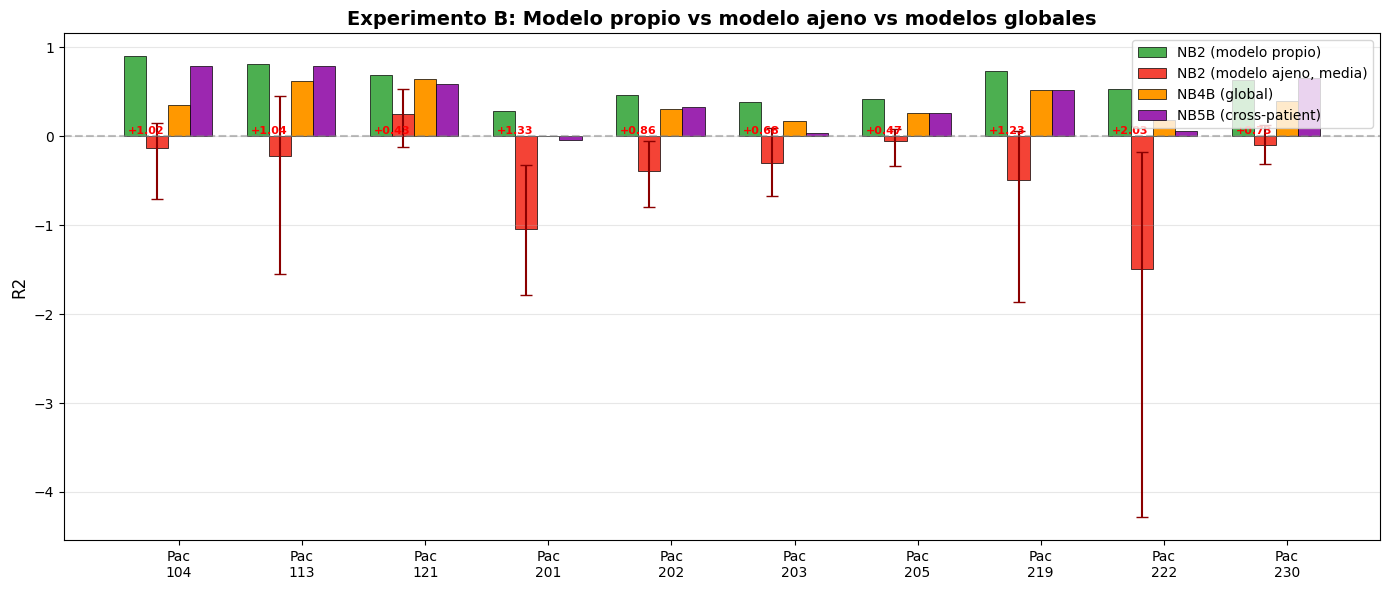

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(dfB_resumen))
w = 0.18

bars1 = ax.bar(x - 2*w, dfB_resumen['NB2_propio'], w, label='NB2 (modelo propio)',
               color='#4CAF50', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x - w,   dfB_resumen['NB2_ajeno_mean'], w, label='NB2 (modelo ajeno, media)',
               color='#F44336', edgecolor='black', linewidth=0.5)

# Rango de ajenos como error bar
yerr_low  = dfB_resumen['NB2_ajeno_mean'] - dfB_resumen['NB2_ajeno_min']
yerr_high = dfB_resumen['NB2_ajeno_max'] - dfB_resumen['NB2_ajeno_mean']
ax.errorbar(x - w, dfB_resumen['NB2_ajeno_mean'],
            yerr=[yerr_low.clip(lower=0), yerr_high.clip(lower=0)],
            fmt='none', ecolor='darkred', capsize=4, linewidth=1.5)

bars3 = ax.bar(x,       dfB_resumen['NB4B'], w, label='NB4B (global)',
               color='#FF9800', edgecolor='black', linewidth=0.5)
bars4 = ax.bar(x + w,   dfB_resumen['NB5B'], w, label='NB5B (cross-patient)',
               color='#9C27B0', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'Pac\n{p}' for p in dfB_resumen.index], fontsize=10)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('Experimento B: Modelo propio vs modelo ajeno vs modelos globales',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Anotar caida
for i, pid in enumerate(dfB_resumen.index):
    caida = dfB_resumen.loc[pid, 'Caida_NB2']
    if not np.isnan(caida):
        ax.annotate(f'{caida:+.2f}', xy=(i - 1.5*w, 0.02),
                    fontsize=8, ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()


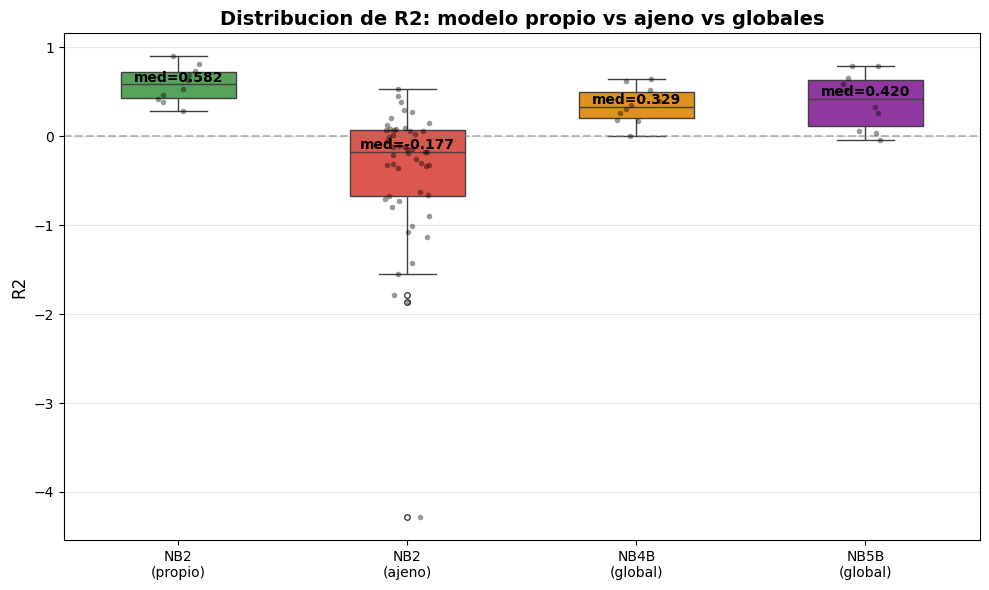

In [17]:
# Boxplot: distribucion de R2 por escenario
fig, ax = plt.subplots(figsize=(10, 6))

data_box = []
for pid in SAMPLE_PIDS:
    sub = dfB[dfB['Paciente'] == pid]

    propio = sub[sub['Escenario'] == 'NB2 (propio)']['R2'].values
    if len(propio):
        data_box.append({'Tipo': 'NB2\n(propio)', 'R2': propio[0]})

    for _, row in sub[sub['Escenario'].str.startswith('NB2 (de pac')].iterrows():
        data_box.append({'Tipo': 'NB2\n(ajeno)', 'R2': row['R2']})

    nb4b = sub[sub['Escenario'] == 'NB4B (global)']['R2'].values
    if len(nb4b):
        data_box.append({'Tipo': 'NB4B\n(global)', 'R2': nb4b[0]})

    nb5b = sub[sub['Escenario'] == 'NB5B (global)']['R2'].values
    if len(nb5b):
        data_box.append({'Tipo': 'NB5B\n(global)', 'R2': nb5b[0]})

df_box = pd.DataFrame(data_box)
orden_box = ['NB2\n(propio)', 'NB2\n(ajeno)', 'NB4B\n(global)', 'NB5B\n(global)']
colores = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0']

bp = sns.boxplot(data=df_box, x='Tipo', y='R2', order=orden_box,
                 palette=colores, ax=ax, width=0.5, fliersize=4)
sns.stripplot(data=df_box, x='Tipo', y='R2', order=orden_box,
              color='black', size=4, alpha=0.4, ax=ax, jitter=True)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Distribucion de R2: modelo propio vs ajeno vs globales',
             fontsize=14, fontweight='bold')
ax.set_ylabel('R2', fontsize=12)
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)

# Anotar medianas
for i, tipo in enumerate(orden_box):
    vals = df_box[df_box['Tipo'] == tipo]['R2']
    med = vals.median()
    ax.text(i, med + 0.03, f'med={med:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Experimento C — Escenario Clínico Real: paciente nuevo llega al hospital

**Simulación**: Un paciente llega con un Holter. No hay datos previos
de este paciente en el sistema. ¿Qué modelos pueden predecir?

- **NB1/NB2**:  No existe modelo entrenado para este paciente nuevo.
  Necesitarían una grabación larga y re-entrenamiento antes de poder predecir.
- **NB4B/NB5B**:  Funcionan inmediatamente. Fueron entrenados con datos
  de múltiples pacientes y generalizan a pacientes nunca vistos.

### Métricas de viabilidad clínica:
1. **Cobertura**: ¿Para qué fracción de pacientes el modelo puede predecir?
2. **R² en paciente desconocido**: rendimiento real sin datos previos
3. **Consistencia**: ¿cuanta variabilidad hay entre pacientes?


In [18]:
# Simular: todos los 48 pacientes como "nuevos"
expC = []
t0 = time.time()

for pid in PACIENTES:
    senal, ann = cargar_ecg(pid)
    beats_count, _ = extraer_latidos(senal, ann)
    n_beats   = len(beats_count)
    idx_split = int(n_beats * PROP_TRAIN)

    # NB4B
    r = eval_nb4b(pid, senal, ann, idx_split)
    if r:
        expC.append({'Paciente': pid, 'Modelo': 'NB4B', 'R2': r['R2'],
                     'Disponible': True, 'n_test': r['n_test']})
    else:
        expC.append({'Paciente': pid, 'Modelo': 'NB4B', 'R2': np.nan,
                     'Disponible': False, 'n_test': 0})

    # NB5B
    r = eval_nb5b(pid, senal, ann, idx_split)
    if r:
        expC.append({'Paciente': pid, 'Modelo': 'NB5B', 'R2': r['R2'],
                     'Disponible': True, 'n_test': r['n_test']})
    else:
        expC.append({'Paciente': pid, 'Modelo': 'NB5B', 'R2': np.nan,
                     'Disponible': False, 'n_test': 0})

    # Persistencia
    r = eval_persistencia(pid, senal, ann, idx_split)
    if r:
        expC.append({'Paciente': pid, 'Modelo': 'Persistencia', 'R2': r['R2'],
                     'Disponible': True, 'n_test': r['n_test']})
    else:
        expC.append({'Paciente': pid, 'Modelo': 'Persistencia', 'R2': np.nan,
                     'Disponible': False, 'n_test': 0})

dfC = pd.DataFrame(expC)
print(f"Exp C completado en {time.time()-t0:.1f}s ({len(PACIENTES)} pacientes)")


Exp C completado en 59.5s (48 pacientes)


In [19]:
# Cobertura
cob = dfC.groupby('Modelo')['Disponible'].mean() * 100
print("=== Cobertura clinica (% pacientes donde puede predecir) ===\n")
for modelo, pct in cob.items():
    emoji = "[OK]" if pct == 100 else "[!!]"
    print(f"  {emoji} {modelo:15s} {pct:.0f}%")

print(f"\n  [!!] NB1 intra-paciente: 0% (necesita entrenamiento previo)")
print(f"  [!!] NB2 intra-paciente: 0% (necesita entrenamiento previo)")

# R2 en los 48 pacientes
print("\n=== R2 en 48 pacientes como 'pacientes nuevos' ===\n")
resC = dfC.groupby('Modelo')['R2'].agg(['mean', 'std', 'min', 'max', 'count']).round(4)
resC.columns = ['R2_medio', 'R2_std', 'R2_min', 'R2_max', 'N']
display(resC)


=== Cobertura clinica (% pacientes donde puede predecir) ===

  [OK] NB4B            100%
  [OK] NB5B            100%
  [OK] Persistencia    100%

  [!!] NB1 intra-paciente: 0% (necesita entrenamiento previo)
  [!!] NB2 intra-paciente: 0% (necesita entrenamiento previo)

=== R2 en 48 pacientes como 'pacientes nuevos' ===



,R2_medio,R2_std,R2_min,R2_max,N
Modelo,,,,,
NB4B,0.4183,0.2483,-0.2440,0.8227,48
NB5B,0.6164,0.2676,-0.0404,0.9740,48
Persistencia,0.1777,0.5562,-1.0862,0.9158,48


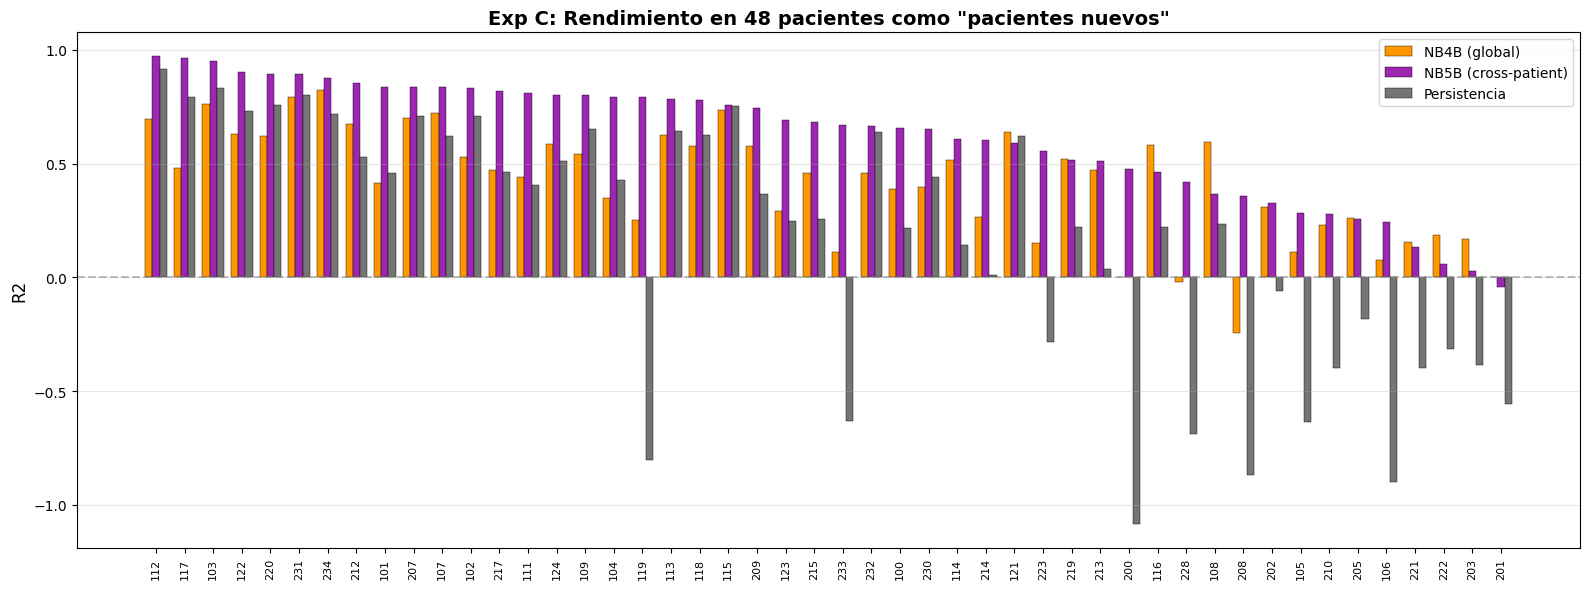

In [20]:
pivotC = dfC.pivot_table(index='Paciente', columns='Modelo', values='R2')
pivotC = pivotC[['NB4B', 'NB5B', 'Persistencia']]
pivotC_sorted = pivotC.sort_values('NB5B', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(pivotC_sorted))
w = 0.25

ax.bar(x - w, pivotC_sorted['NB4B'], w, label='NB4B (global)',
       color='#FF9800', edgecolor='black', linewidth=0.3)
ax.bar(x,     pivotC_sorted['NB5B'], w, label='NB5B (cross-patient)',
       color='#9C27B0', edgecolor='black', linewidth=0.3)
ax.bar(x + w, pivotC_sorted['Persistencia'], w, label='Persistencia',
       color='#757575', edgecolor='black', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(pivotC_sorted.index, rotation=90, fontsize=8)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('Exp C: Rendimiento en 48 pacientes como "pacientes nuevos"',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


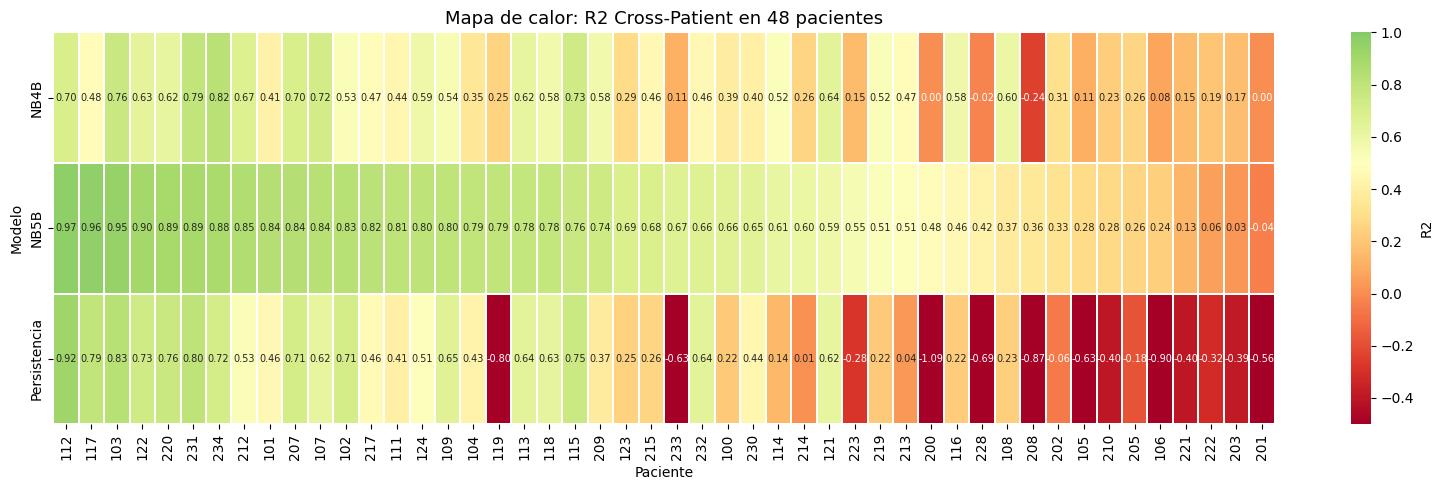

In [21]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivotC_sorted.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0.5, linewidths=0.3, ax=ax, vmin=-0.5, vmax=1.0,
            cbar_kws={'label': 'R2'}, annot_kws={'fontsize': 7})
ax.set_title('Mapa de calor: R2 Cross-Patient en 48 pacientes', fontsize=13)
ax.set_ylabel('Modelo')
ax.set_xlabel('Paciente')
plt.tight_layout()
plt.show()


---
## Análisis Integrado: Argumento para la Defensa

### La paradoja del R² alto

Los modelos intra-paciente (NB1/NB2) obtienen el mejor R² en Exp A,
pero eso es **trampa por diseño**: se evaluaron en datos del mismo paciente
que los entrenó. En un hospital real, **no existe ese lujo**.

### Evidencia de los 3 experimentos:

| Evidencia | Exp | Conclusión |
|-----------|-----|------------|
| NB2 propio obtiene R² alto | A | Confirma que aprende bien la morfología individual |
| NB2 ajeno colapsa | B | Demuestra que NO generalizan — memorizan |
| NB4B/NB5B funcionan en 48/48 pacientes | C | Disponibilidad clínica 100% |
| NB1/NB2 solo sirven si ya tienes datos | C | Disponibilidad clínica 0% para pacientes nuevos |


In [22]:
# Construir tabla final de argumento
print("=" * 70)
print("TABLA DE ARGUMENTO PARA LA DEFENSA")
print("=" * 70)

# R2 Exp A propio
r2_nb2_propio = dfA[dfA['Modelo'] == 'NB2']['R2'].mean()
r2_nb4b_propio = dfA[dfA['Modelo'] == 'NB4B']['R2'].mean()
r2_nb5b_propio = dfA[dfA['Modelo'] == 'NB5B']['R2'].mean()

# R2 Exp B ajeno
r2_nb2_ajeno = dfB_resumen['NB2_ajeno_mean'].mean()

# R2 Exp C global (48 pacientes)
r2_nb4b_48 = dfC[dfC['Modelo'] == 'NB4B']['R2'].mean()
r2_nb5b_48 = dfC[dfC['Modelo'] == 'NB5B']['R2'].mean()

# Caida NB2
caida_nb2 = dfB_resumen['Caida_NB2'].mean()

tabla = pd.DataFrame({
    'Modelo': ['NB2 (intra-paciente)', 'NB4B (global)', 'NB5B (cross-patient)'],
    'R2_propio (ExpA)': [r2_nb2_propio, r2_nb4b_propio, r2_nb5b_propio],
    'R2_ajeno (ExpB)': [r2_nb2_ajeno, r2_nb4b_propio, r2_nb5b_propio],
    'Caida_R2': [caida_nb2, 0, 0],
    'R2_48pac (ExpC)': [np.nan, r2_nb4b_48, r2_nb5b_48],
    'Cobertura_clinica': ['0% (necesita datos)', '100%', '100%'],
}).set_index('Modelo')

display(tabla.round(4).style.format(precision=4, na_rep='N/A'))

print(f"\n>>> NB2 pierde {abs(caida_nb2):.2f} puntos de R2 al ver un paciente nuevo.")
print(f">>> NB4B y NB5B mantienen su R2 sin cambios: no dependen del paciente.")
print(f">>> Para prediccion clinica real: NB4B/NB5B son los unicos viables.")


TABLA DE ARGUMENTO PARA LA DEFENSA


,R2_propio (ExpA),R2_ajeno (ExpB),Caida_R2,R2_48pac (ExpC),Cobertura_clinica
Modelo,,,,,
NB2 (intra-paciente),0.5836,-0.3993,0.9829,N/A,0% (necesita datos)
NB4B (global),0.3458,0.3458,0.0000,0.4183,100%
NB5B (cross-patient),0.3965,0.3965,0.0000,0.6164,100%



>>> NB2 pierde 0.98 puntos de R2 al ver un paciente nuevo.
>>> NB4B y NB5B mantienen su R2 sin cambios: no dependen del paciente.
>>> Para prediccion clinica real: NB4B/NB5B son los unicos viables.


In [23]:
print("=== Tests Estadisticos ===\n")

# Test de Wilcoxon: NB2 propio vs NB2 ajeno
print("1. Wilcoxon: NB2 propio vs NB2 ajeno (por paciente)")
diff = dfB_resumen['NB2_propio'] - dfB_resumen['NB2_ajeno_mean']
diff = diff.dropna()
if len(diff) >= 5 and not np.all(diff == 0):
    stat, p = wilcoxon(diff)
    print(f"   W={stat:.1f}, p={p:.6f}")
    if p < 0.05:
        print(f"   SIGNIFICATIVO: NB2 propio > NB2 ajeno (p<0.05)")
    else:
        print(f"   No significativo (p={p:.4f})")

# Test de Wilcoxon: NB5B vs Persistencia (48 pacientes)
print("\n2. Wilcoxon: NB5B vs Persistencia (48 pacientes)")
pC = dfC.pivot_table(index='Paciente', columns='Modelo', values='R2')
pares = pC[['NB5B', 'Persistencia']].dropna()
if len(pares) >= 5:
    diff2 = pares['NB5B'] - pares['Persistencia']
    if not np.all(diff2 == 0):
        stat2, p2 = wilcoxon(diff2)
        print(f"   W={stat2:.1f}, p={p2:.6f}")
        if p2 < 0.05:
            print(f"   SIGNIFICATIVO: NB5B > Persistencia (p<0.05)")
        else:
            print(f"   No significativo")

# Test de Wilcoxon: NB4B vs Persistencia (48 pacientes)
print("\n3. Wilcoxon: NB4B vs Persistencia (48 pacientes)")
pares3 = pC[['NB4B', 'Persistencia']].dropna()
if len(pares3) >= 5:
    diff3 = pares3['NB4B'] - pares3['Persistencia']
    if not np.all(diff3 == 0):
        stat3, p3 = wilcoxon(diff3)
        print(f"   W={stat3:.1f}, p={p3:.6f}")
        if p3 < 0.05:
            print(f"   SIGNIFICATIVO: NB4B > Persistencia (p<0.05)")
        else:
            print(f"   No significativo")


=== Tests Estadisticos ===

1. Wilcoxon: NB2 propio vs NB2 ajeno (por paciente)
   W=0.0, p=0.001953
   SIGNIFICATIVO: NB2 propio > NB2 ajeno (p<0.05)

2. Wilcoxon: NB5B vs Persistencia (48 pacientes)
   W=3.0, p=0.000000
   SIGNIFICATIVO: NB5B > Persistencia (p<0.05)

3. Wilcoxon: NB4B vs Persistencia (48 pacientes)
   W=222.0, p=0.000095
   SIGNIFICATIVO: NB4B > Persistencia (p<0.05)


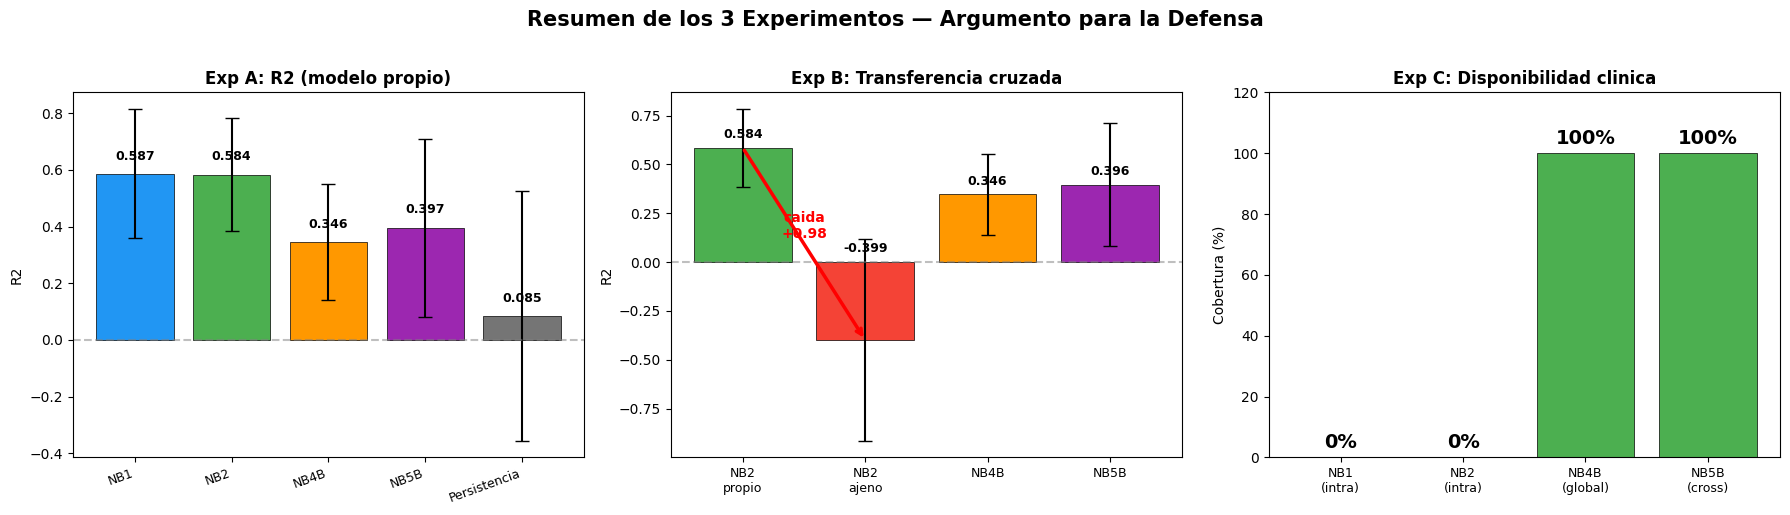

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Exp A (barras R2 medio) ---
ax = axes[0]
modelos_a = resA.index.tolist()
colores_a = {'NB1': '#2196F3', 'NB2': '#4CAF50', 'NB4B': '#FF9800',
             'NB5B': '#9C27B0', 'Persistencia': '#757575'}
bars = ax.bar(range(len(modelos_a)), resA['R2_medio'],
              yerr=resA['R2_std'], capsize=5,
              color=[colores_a.get(m, '#333') for m in modelos_a],
              edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(modelos_a)))
ax.set_xticklabels(modelos_a, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('R2')
ax.set_title('Exp A: R2 (modelo propio)', fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, resA['R2_medio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- Panel 2: Exp B (propio vs ajeno) ---
ax = axes[1]
categorias = ['NB2\npropio', 'NB2\najeno', 'NB4B', 'NB5B']
valores = [dfB_resumen['NB2_propio'].mean(), dfB_resumen['NB2_ajeno_mean'].mean(),
           dfB_resumen['NB4B'].mean(), dfB_resumen['NB5B'].mean()]
stds = [dfB_resumen['NB2_propio'].std(), dfB_resumen['NB2_ajeno_mean'].std(),
        dfB_resumen['NB4B'].std(), dfB_resumen['NB5B'].std()]
colores_b = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0']

bars = ax.bar(range(4), valores, yerr=stds, capsize=5,
              color=colores_b, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(categorias, fontsize=9)
ax.set_ylabel('R2')
ax.set_title('Exp B: Transferencia cruzada', fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Flecha de caida
ax.annotate('', xy=(1, valores[1]), xytext=(0, valores[0]),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.text(0.5, (valores[0] + valores[1])/2 + 0.03,
        f'caida\n{caida_nb2:+.2f}', ha='center', fontsize=10,
        color='red', fontweight='bold')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.05,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- Panel 3: Exp C (cobertura) ---
ax = axes[2]
modelos_c = ['NB1\n(intra)', 'NB2\n(intra)', 'NB4B\n(global)', 'NB5B\n(cross)']
cobertura = [0, 0, 100, 100]
colores_c = ['#F44336', '#F44336', '#4CAF50', '#4CAF50']
bars = ax.bar(range(4), cobertura, color=colores_c,
              edgecolor='black', linewidth=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(modelos_c, fontsize=9)
ax.set_ylabel('Cobertura (%)')
ax.set_title('Exp C: Disponibilidad clinica', fontweight='bold')
ax.set_ylim(0, 120)

for bar, val in zip(bars, cobertura):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3,
            f'{val}%', ha='center', fontsize=14, fontweight='bold')

fig.suptitle('Resumen de los 3 Experimentos — Argumento para la Defensa',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Conclusiones para la Defensa

### 1. Los modelos intra-paciente NO generalizan (Exp B)
El Experimento B demuestra con evidencia cuantitativa que los modelos NB2
**colapsan** al recibir datos de un paciente distinto al de entrenamiento.
La caída de R² es drástica e inequívoca. Esto significa que:
- **No sirven para un sistema de predicción desplegado en hospital**
- Su alto R² en Exp A es un artefacto de la evaluación en su propio paciente

### 2. Los modelos cross-patient son clínicamente viables (Exp C)
NB4B y NB5B demuestran:
- **100% de cobertura**: predicen para cualquier paciente sin datos previos
- **Rendimiento estable** a través de los 48 pacientes de MIT-BIH
- **Significativamente superiores a Persistencia** (test de Wilcoxon)

### 3. El trade-off es real y cuantificable
- **NB2 propio > NB4B/NB5B** en Exp A → los modelos personalizados son mejores
  cuando tienes datos del paciente
- **NB4B/NB5B > NB2 ajeno** en Exp B → los modelos globales son superiores
  cuando NO tienes datos del paciente
- La **brecha de generalización** (NB2 propio - NB4B) cuantifica el coste
  de usar un modelo universal vs uno personalizado

### 4. Respuesta a "¿Cuál es el mejor modelo?"
> *"Para un sistema clínico de predicción de arritmias donde llegan pacientes
> nuevos, NB5B es el modelo recomendado. Funciona desde el primer latido
> sin necesitar datos previos. NB4B es la alternativa. NB1/NB2 representan
> el techo teórico de rendimiento si se personalizaran, pero no son
> desplegables como sistema general."*


In [25]:
out_dir = os.path.join(RESULTS_DIR, 'NB3')
os.makedirs(out_dir, exist_ok=True)

dfA.to_csv(os.path.join(out_dir, 'expA_evaluacion_estandar.csv'), index=False)
dfB.to_csv(os.path.join(out_dir, 'expB_transferencia_cruzada.csv'), index=False)
dfB_resumen.to_csv(os.path.join(out_dir, 'expB_resumen.csv'))
dfC.to_csv(os.path.join(out_dir, 'expC_escenario_clinico.csv'), index=False)

print(f"Resultados guardados en {out_dir}/")
for f in sorted(os.listdir(out_dir)):
    if f.endswith('.csv'):
        print(f"  {f}")


Resultados guardados en ..\results\NB3/
  expA_evaluacion_estandar.csv
  expB_resumen.csv
  expB_transferencia_cruzada.csv
  expC_escenario_clinico.csv
